In [12]:
import math as m 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

# --- Math helpers ----
def log_beta(a,b): 
    from math import lgamma as LG #lgamma is the log of the gamma function. 
    return LG(a) + LG(b) - LG(a+b) 

def gamma_sf(alpha, beta, x):
    """ 
    Parameters: 
    ------
    - alpha: alpha is shape that is >0 
    - beta: beta is rate that is >0 

    Return: Survival P(X>=x) for Gamma(shape=alpha, rate=beta)
    ------
    - For integer alpha<=5: closed form using Poisson-tailed identity. 
    - Else: crude numerical tail integration (sufficient for demo)
    - trapz: trapezoidal integration, which is more accurate than simpson for non-smooth functions. 
    """
    if abs(alpha - int(alpha)) < 1e-12 and int(alpha) <= 5:
        k = int(alpha) 
        s = 0.0 
        for j in range(k):
            s += ((beta * x )**j) / np.math.factorial(j) 
        return np.exp(-beta * x) * s 
    xs = np.linspace(x, x + 200 / beta, 20000) 
    fx = (beta ** alpha) / np.exp(lgamma(alpha)) * (xs ** (alpha -1)) * np.exp(-beta * xs) 
    return np.trapz(fx, xs) 

# --- Conjugate-updating simulators ---
def beta_update_trajectory(p_true, a0, b0, n_trials): 
    """ 
    Simulate Bernoulli observations with p_true, return posterior mean E[p|data] per step and the observations.
    """
    a, b = float(a0), float(b0) 
    means = np.zeros(n_trials, dtype=float) 
    obs = np.random.binomial(1, p_true, size=n_trials) # Likelihood
    for t, x in enumerate(obs):
        a += x
        b += 1 - x 
        means[t] = a / (a + b) 
    return means, obs 

def dirichlet_update_trajectory(true_probs, alpha0, n_trials):
    """ 
    Simulate categorical obs; return posterior mean vector per step and the observations.
    - true_probs: list of true probabilities for each category, sums to 1. 
    - alpha0: list of prior concentration parameters for each category, >0. 
    - n_trials: number of trials to simulate. 

    Note:
    - Dirichlet is conjugate prior to Categorical ; posterior is also Dirichlet.
    """
    true_probs = np.asarray(true_probs, dtype=float)
    k = len(true_probs) 
    alpha = np.asarray(alpha0, dtype=float).copy() 
    means = np.zeros((n_trials, k), dtype=float) 
    obs = np.random.choice(k, size=n_trials, p=true_probs) 
    for t, o in enumerate(obs):
        alpha[o] += 1.0 
        means[t] = alpha / alpha.sum() 
    return means, obs


# --- Scenario-specific untility functions --- 
def prob_ends_in_5(p): 
    """ 
    Best-of-7, exactly 5 games: 4 choose 3 * p^4 * (1-p) + symmetric term 
    """
    return 4 * (p ** 4) * (1 - p) + 4 * ((1 - p) ** 4) * p 


# --- Plotters --- 
def base_plot_setting(title, xlabel, ylabel, axhline=None, figsize=(8,3)):
    import matplotlib.pyplot as plt 
    plt.figure(figsize=figsize)
    plt.title(title, fontsize=10)
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel(ylabel, fontsize=8)
    if axhline is not None:
        plt.axhline(y=axhline, color='r', linestyle='--', alpha=0.5)

def plot_ex1_dirichlet_die(true_die, prior_probs, m_strength=30, n_rolls=300, show=True):
    alpha0 = np.asarray(prior_probs, dtype=float) * float(m_strength) 
    means, obs = dirichlet_update_trajectory(true_die, alpha0, n_rolls)

    base_plot_setting(
        title ='Ex1) Dice: Posterior Mean per Face (Dirichlet-Cagegorical)',
        xlabel='Rolls', 
        ylabel='Posterior mean probability',
        )
    for face in range(len(true_die)): 
        plt.plot(np.arange(1, n_rolls +1), means[:, face], label=f'Face {face+1}')
     
    if show:
        plt.legend(loc='best')
        plt.show()
    return means, obs 

def plot_ex2_bus_wait(p_true=5/30, a0=4, b0=6, n_trials=300, show=True):
    means, obs = beta_update_trajectory(p_true, a0, b0, n_trials)
    base_plot_setting(
        title='Ex2) Bus wait ≤ 5 min: Posterior Mean of p (Beta-Bernoulli)',
        xlabel='Trials', 
        ylabel='Posterial mean probability',
    )
    plt.plot(np.arange(1, n_trials +1), means) 


def plot_ex3_lottery(p_true=1e-3, prior_mean=1e-7, prior_strength=10.0, n_weeks=1000, show=True):
    """ 
    - p_true: true prob of winning lottery per week. 
    - prior_mean: prior mean of p. 
    - prior_strength: prior strength (pseduo-counts). 
    - n_weeks: number of weeks to simulate  
    """
    a0 = prior_mean * prior_strength # prior_strength is like pseudo-counts 
    b0 = (1 - prior_mean) * prior_strength 
    a, b = a0, b0 
    means = [] 
    hit_week = None 
    for week in range(1, n_weeks +1): 
        x = np.random.binomial(1, p_true) 
        a += x 
        b += 1 - x 
        means.append(a / (a + b)) 
        if x == 1 and hit_week is None: 
            hit_week = week 
        if hit_week is not None and week >= hit_week + 100: 
            break 
    means = np.array(means) 

    base_plot_setting(
        title = 'Ex3) Lottery: Posterial mean of p week-by-week (Beta-Bernoulli)',
        xlabel= 'Weeks',
        ylabel= 'Posterior mean prob'
    )
    plt.plot(np.arange(1, len(means)+1), means) 

    # table of P(T=7): true, prior predictive, plug-in after 6 fails
    true_prob = (1 - p_true)**6 * p_true 
    log_pp = log_beta(a0 + 1, b0 + 6) - log_beta(a0, b0) 
    prior_pred = m.exp(log_pp) 
    a6, b6 = a0, b0 + 6 # add the number of fails
    plug_in_p = a6 / (a6 + b6) 
    plug_in_pred = (1 - plug_in_p)**6 * plug_in_p 
    table = pd.DataFrame({
        'Quantity': ['True P(T=7)', 'Prior Predictive P(T=7)', 'Plug-in after 6 fails'],
        'Value': [true_prob, prior_pred, plug_in_pred] 
    })
    return means, hit_week, table 


def plot_ex4_bestof7(p_true=0.7, prior_center=0.3, prior_strength=20.0, n_games=200, show=True):
    a0, b0 = prior_center * prior_strength, (1-prior_center)*prior_strength
    means, obs = beta_update_trajectory(p_true, a0, b0, n_games)
    plug_in_series5 = np.array([prob_ends_in_5(mu) for mu in means]) 

    base_plot_setting(
        title='Ex4) Per-game win p for A: Posterior Mean (Beta-Bernoulli)',
        xlabel= 'Games Observed',
        ylabel='Posterior mean'
    )
    plt.plot(np.arange(1, n_games +1), means) 
    if show:
        plt.show() 
    
    true_end5 = prob_ends_in_5(p_true) 
    base_plot_setting(
        title= 'Ex4) P(series ends in 5 games) via plug-in over learning',
        xlabel= 'Game observed',
        ylabel='Estimated P(end in 5)',
        axhline=true_end5
    )
    plt.plot(np.arange(1, n_games +1), plug_in_series5)
    if show:
        plt.show() 
    return means, obs, plug_in_series5, true_end5 


def table_ex5_gamma(alpha_true=2.0, beta_true=4.0, x_obs=20.0, alpha_user=1.0, beta_user=6.0):
    tail_true = gamma_sf(alpha_true, beta_true, x_obs)
    tail_user = gamma_sf(alpha_user, beta_user, x_obs) 
    beta_hat = alpha_true / x_obs 
    tail_plugin = gamma_sf(alpha_true, beta_hat, x_obs) 
    df = pd.DataFrame({
        "Model": [f"True: Gamma({alpha_true}, {beta_true})", 
                  f"User assumed: Gamma({alpha_user}, {beta_user})",
                  f"Plug-in after observing x={x_obs:g}"],
        "P(X \u2265 x)": [tail_true, tail_user, tail_plugin] 
    })
    return df 

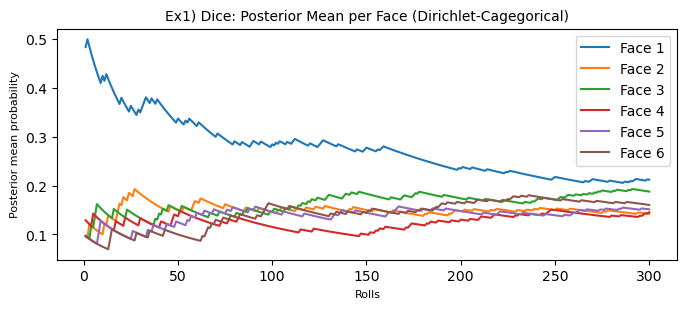

(array([[0.48387097, 0.09677419, 0.09677419, 0.12903226, 0.09677419,
         0.09677419],
        [0.5       , 0.09375   , 0.09375   , 0.125     , 0.09375   ,
         0.09375   ],
        [0.48484848, 0.12121212, 0.09090909, 0.12121212, 0.09090909,
         0.09090909],
        ...,
        [0.21036585, 0.14329268, 0.18902439, 0.14329268, 0.15243902,
         0.16158537],
        [0.21276596, 0.14285714, 0.18844985, 0.14285714, 0.15197568,
         0.16109422],
        [0.21212121, 0.14242424, 0.18787879, 0.14545455, 0.15151515,
         0.16060606]]),
 array([3, 0, 1, 2, 3, 2, 2, 4, 4, 0, 1, 0, 1, 5, 5, 2, 3, 1, 1, 0, 1, 3,
        2, 1, 0, 4, 1, 5, 0, 3, 0, 0, 0, 4, 5, 0, 4, 2, 0, 2, 3, 2, 5, 4,
        2, 1, 3, 3, 4, 0, 3, 2, 1, 0, 4, 0, 4, 1, 1, 4, 0, 1, 5, 4, 5, 5,
        2, 5, 4, 5, 0, 2, 3, 5, 1, 4, 3, 5, 4, 0, 2, 3, 5, 0, 2, 1, 2, 4,
        0, 0, 4, 5, 1, 0, 5, 5, 5, 5, 2, 0, 2, 0, 1, 0, 1, 4, 2, 0, 5, 2,
        0, 0, 1, 2, 3, 2, 4, 1, 2, 0, 2, 3, 1, 2, 0, 0, 0, 1, 2, 2, 5

In [9]:
# Ex1
true_die = np.ones(6) / 6 
prior_probs = np.array([0.5] + [0.1] *5) 
plot_ex1_dirichlet_die(true_die, prior_probs, m_strength=30, n_rolls=300, show=True) 


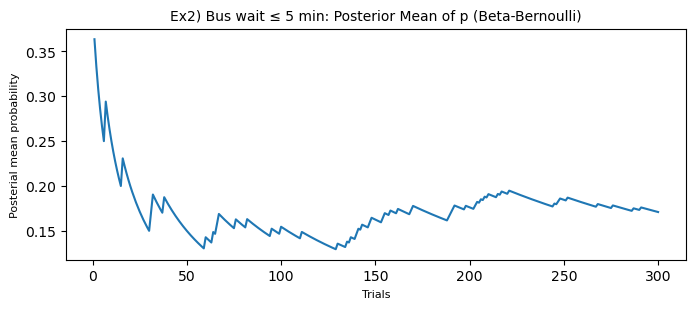

In [11]:
# Ex2
plot_ex2_bus_wait(p_true=5/30, a0=4, b0=6, n_trials=300, show=True) 



Ex3: First success at week 7 probabilities: 
                Quantity        Value
            True P(T=7) 9.940150e-04
Prior Predictive P(T=7) 6.249997e-08
  Plug-in after 6 fails 6.249998e-08


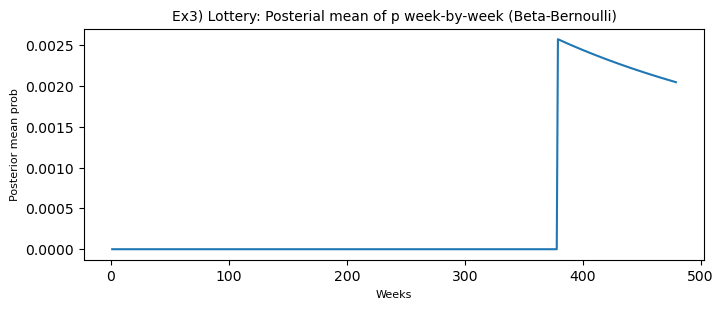

In [13]:
# Ex3
means3, hit_week, table3 = plot_ex3_lottery(p_true=0.001, prior_strength=10.0, n_weeks=1000, show=True) 
print("\nEx3: First success at week 7 probabilities: \n", table3.to_string(index=False))


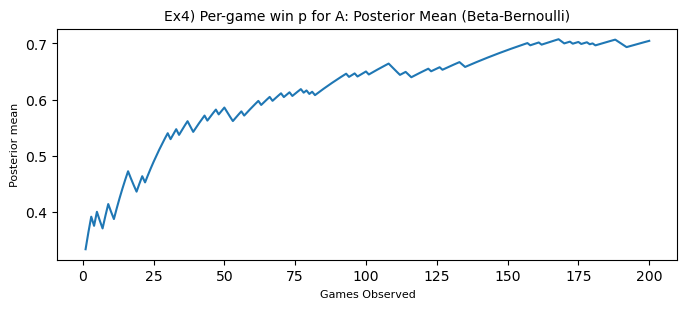

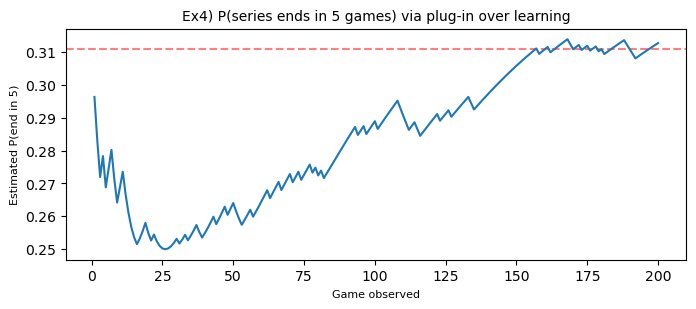


Ex4: True P(series ends in 5) = 0.310800


In [14]:
# Ex4
means4, obs4, plug_in_series5, true_ends5 = plot_ex4_bestof7(p_true=0.7, prior_center=0.3, prior_strength=20.0, n_games=200, show=True)
print(f"\nEx4: True P(series ends in 5) = {true_ends5:.6f}")

In [15]:
# Ex5
table5 = table_ex5_gamma(alpha_true=2.0, beta_true=4.0, x_obs=20.0, alpha_user=1.0, beta_user=6.0)
print("\nEx5: Tail probabilities:\n", table5.to_string(index=False))


Ex5: Tail probabilities:
                         Model     P(X ≥ x)
        True: Gamma(2.0, 4.0) 1.461930e-33
User assumed: Gamma(1.0, 6.0) 7.667648e-53
 Plug-in after observing x=20 4.060058e-01


/tmp/ipykernel_76467/2427844149.py:28: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  s += ((beta * x )**j) / np.math.factorial(j)
